<a href="https://colab.research.google.com/github/smybilginn/ml-midterm-classicml-pca-lda-shap/blob/main/ML_Midterm_ClassicML_PCA_LDA_SHAP_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

1. Veri Setini Yükle

In [ ]:
data = load_breast_cancer()

2. Özellikler (X) ve hedef (y)

In [ ]:
X = data.data
y = data.target

3. DataFrame'e dönüştür

In [ ]:
X_df = pd.DataFrame(X, columns=data.feature_names)
y_df = pd.DataFrame(y, columns=["target"])

4. İlk 5 satırı göster

In [ ]:
print("X_df ilk 5 satır:")
display(X_df.head())

print("y_df ilk 5 satır:")
display(y_df.head())

X_df ilk 5 satır:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


y_df ilk 5 satır:


,target
0,0
1,0
2,0
3,0
4,0


#2. **Veri Seti Kalite Kontrolleri**

2.1. Eksik Değer (Missing Value) Kontrolü

In [ ]:
X_df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Eksik değer yok.

2.2 Aykırı Değer (Outlier) Analizi

IQR yöntemi

In [ ]:
# --- IQR hesaplama ---
Q1 = X_df.quantile(0.25)
Q3 = X_df.quantile(0.75)
IQR = Q3 - Q1

# --- Alt ve üst sınırlar ---
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# --- Sınırları tablo halinde göster ---
bounds_df = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound
})

print("=== IQR Sınır Tablosu ===")
display(bounds_df)

# --- Outlier maskesi ---
outlier_mask = (X_df < lower_bound) | (X_df > upper_bound)

# --- Her sütundaki outlier sayısı ---
outlier_counts = outlier_mask.sum()

print("\n=== Sütunlara Göre Outlier Sayısı ===")
print(outlier_counts)

# --- Toplam outlier içeren satır sayısı ---
total_outlier_rows = outlier_mask.any(axis=1).sum()
print("\nToplam outlier içeren satır sayısı:", total_outlier_rows)


=== IQR Sınır Tablosu ===


,Q1,Q3,IQR,Lower Bound,Upper Bound
mean radius,11.700000,15.780000,4.080000,5.580000,21.900000
mean texture,16.170000,21.800000,5.630000,7.725000,30.245000
mean perimeter,75.170000,104.100000,28.930000,31.775000,147.495000
mean area,420.300000,782.700000,362.400000,-123.300000,1326.300000
mean smoothness,0.086370,0.105300,0.018930,0.057975,0.133695
mean compactness,0.064920,0.130400,0.065480,-0.033300,0.228620
mean concavity,0.029560,0.130700,0.101140,-0.122150,0.282410
mean concave points,0.020310,0.074000,0.053690,-0.060225,0.154535
mean symmetry,0.161900,0.195700,0.033800,0.111200,0.246400
mean fractal dimension,0.057700,0.066120,0.008420,0.045070,0.078750



=== Sütunlara Göre Outlier Sayısı ===
mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64

Toplam outlier içeren satır sayısı: 171


Z - Score Yöntemi

In [ ]:
from scipy import stats
import numpy as np

# Z-score hesapla
z_scores = np.abs(stats.zscore(X_df))

# Threshold
threshold = 3

# Aykırı değerleri bul
outliers_z = (z_scores > threshold)

# Her sütundaki aykırı değer sayısı
outlier_counts_z = outliers_z.sum(axis=0)

print(outlier_counts_z)

[ 5  4  7  8  5  9  9  6  5  7  7  9  8  6  7 12  6  6 11 10  6  4  6 10
  3 10  7  0  9  9]


Boxplot

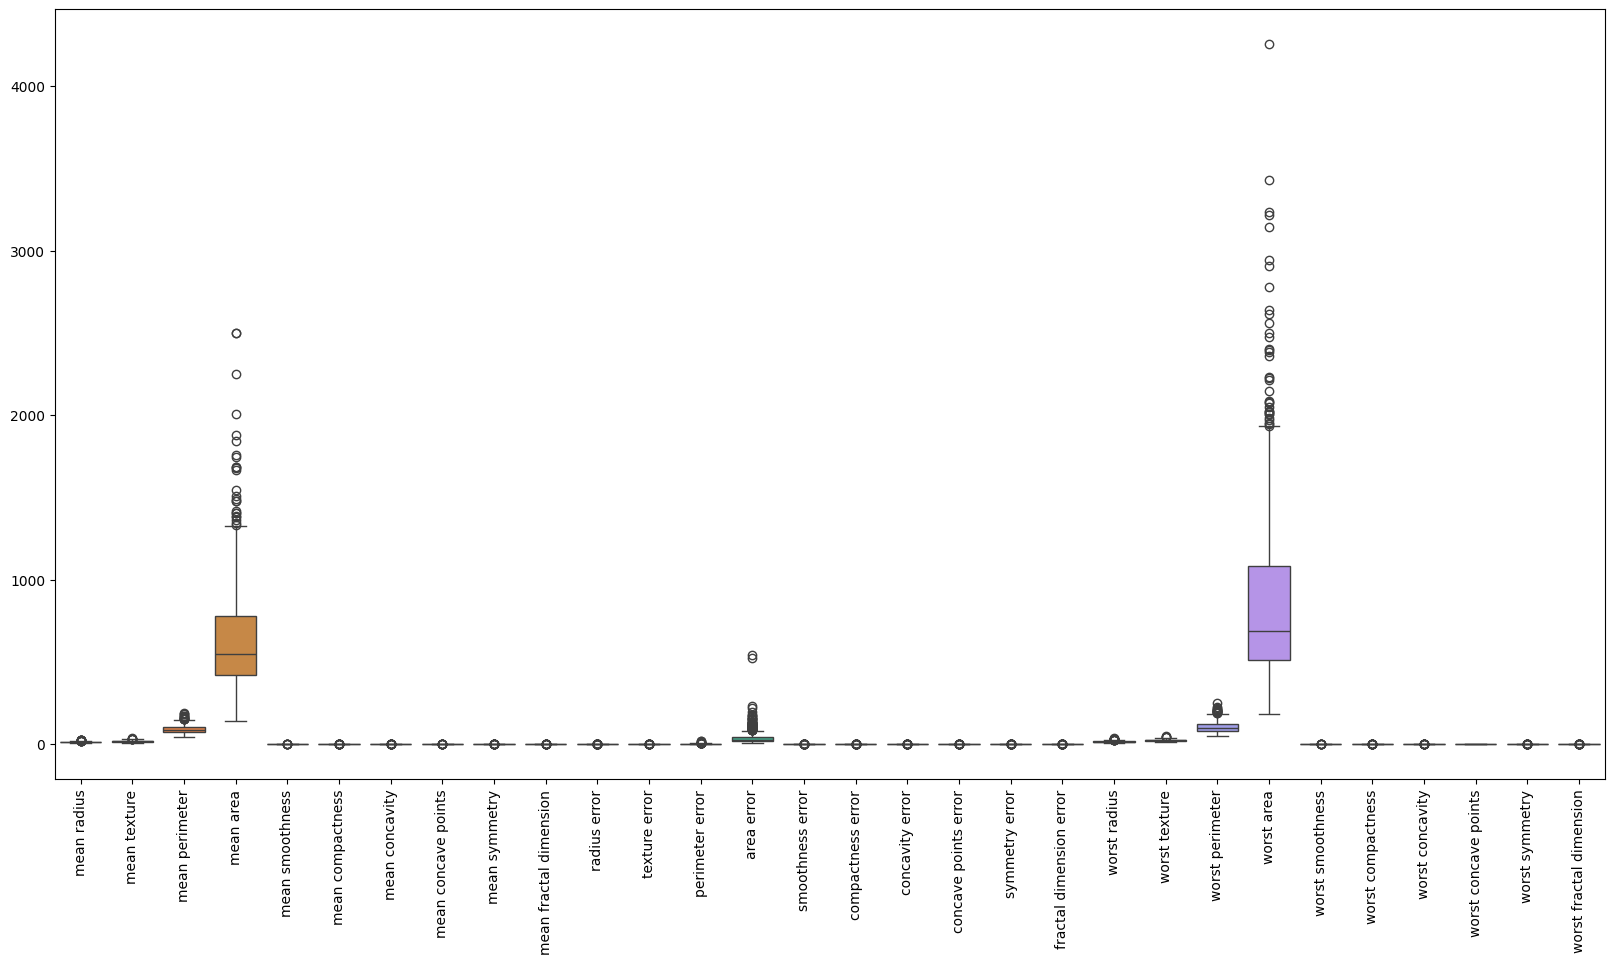

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,10))
sns.boxplot(data=X_df)

plt.xticks(rotation=90)
plt.show()

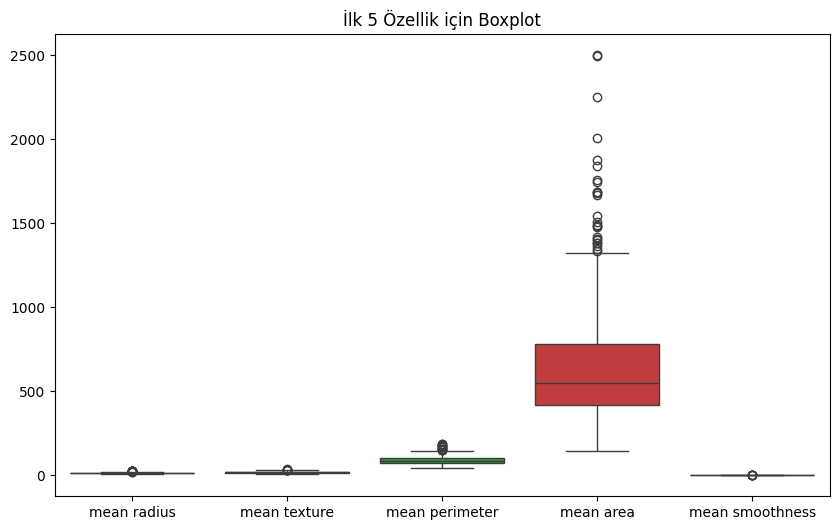

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=X_df.iloc[:, :5])

plt.title("İlk 5 Özellik için Boxplot")
plt.show()

#2.3 Veri Tipi ve Dağılım İncelemesi

In [ ]:
X_df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


Tüm feature'lar sayısal (numeric)

Sayısal / Kategorik sayısı

In [ ]:
# Sayısal sütunlar
numeric_cols = X_df.select_dtypes(include=['int64', 'float64']).columns

# Kategorik sütunlar
categorical_cols = X_df.select_dtypes(include=['object', 'category']).columns

print("Sayısal değişken sayısı:", len(numeric_cols))
print("Kategorik değişken sayısı:", len(categorical_cols))

Sayısal değişken sayısı: 30
Kategorik değişken sayısı: 0


#3. **Keşifsel Veri Analizi (EDA)**

3.1 İstatistiksel Özellikler

In [ ]:
stats_df = pd.DataFrame({
    "Mean": X_df.mean(),
    "Median": X_df.median(),
    "Min": X_df.min(),
    "Max": X_df.max(),
    "Std": X_df.std(),
    "Q1": X_df.quantile(0.25),
    "Q3": X_df.quantile(0.75)
})

display(stats_df)

,Mean,Median,Min,Max,Std,Q1,Q3
mean radius,14.127292,13.370000,6.981000,28.11000,3.524049,11.700000,15.780000
mean texture,19.289649,18.840000,9.710000,39.28000,4.301036,16.170000,21.800000
mean perimeter,91.969033,86.240000,43.790000,188.50000,24.298981,75.170000,104.100000
mean area,654.889104,551.100000,143.500000,2501.00000,351.914129,420.300000,782.700000
mean smoothness,0.096360,0.095870,0.052630,0.16340,0.014064,0.086370,0.105300
mean compactness,0.104341,0.092630,0.019380,0.34540,0.052813,0.064920,0.130400
mean concavity,0.088799,0.061540,0.000000,0.42680,0.079720,0.029560,0.130700
mean concave points,0.048919,0.033500,0.000000,0.20120,0.038803,0.020310,0.074000
mean symmetry,0.181162,0.179200,0.106000,0.30400,0.027414,0.161900,0.195700
mean fractal dimension,0.062798,0.061540,0.049960,0.09744,0.007060,0.057700,0.066120


### İstatistiksel Özellikler (stats_df) Tablosunun Yorumlanması

Bu tablo, `X_df` DataFrame'indeki her bir özellik (sütun) için aşağıdaki temel istatistiksel özetleri sunar:

*   **Mean (Ortalama):** Her özelliğin aritmetik ortalamasını gösterir. Veri setinin merkez eğilimini belirtir.
*   **Median (Medyan):** Her özelliğin sıralanmış değerlerinin ortasındaki değeri gösterir. Aykırı değerlerden ortalamaya göre daha az etkilenir.
*   **Min (Minimum):** Her özelliğin en küçük değerini gösterir.
*   **Max (Maksimum):** Her özelliğin en büyük değerini gösterir.
*   **Std (Standart Sapma):** Her özelliğin değerlerinin ortalamadan ne kadar uzaklaştığını gösterir. Yüksek standart sapma, verilerin daha geniş bir aralığa yayıldığını, düşük standart sapma ise verilerin ortalama etrafında toplandığını gösterir.
*   **Q1 (Birinci Çeyreklik - %25):** Verilerin %25'inin bu değerden küçük olduğunu gösterir.
*   **Q3 (Üçüncü Çeyreklik - %75):** Verilerin %75'inin bu değerden küçük olduğunu gösterir (yani %25'inin bu değerden büyük olduğunu gösterir).

Bu istatistikler sayesinde, her bir özelliğin ortalama değerini, veri aralığını ve veri dağılımının genel şeklini hızlıca anlayabiliriz. Örneğin, 'mean radius' özelliğine bakıldığında, ortalama yarıçapın yaklaşık 14.13, en düşük yarıçapın 6.981 ve en yüksek yarıçapın 28.11 olduğunu görebiliriz. Medyanın ortalamaya yakın olması, dağılımın nispeten simetrik olabileceğini düşündürürken, farklar çarpık (skewed) dağılımlara işaret edebilir.

3.2 Korelasyon Matrisi

Pearson Korelasyon Matrisi

In [ ]:
corr_matrix = X_df.corr()

display(corr_matrix)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


Heatmap ile görselleştirme

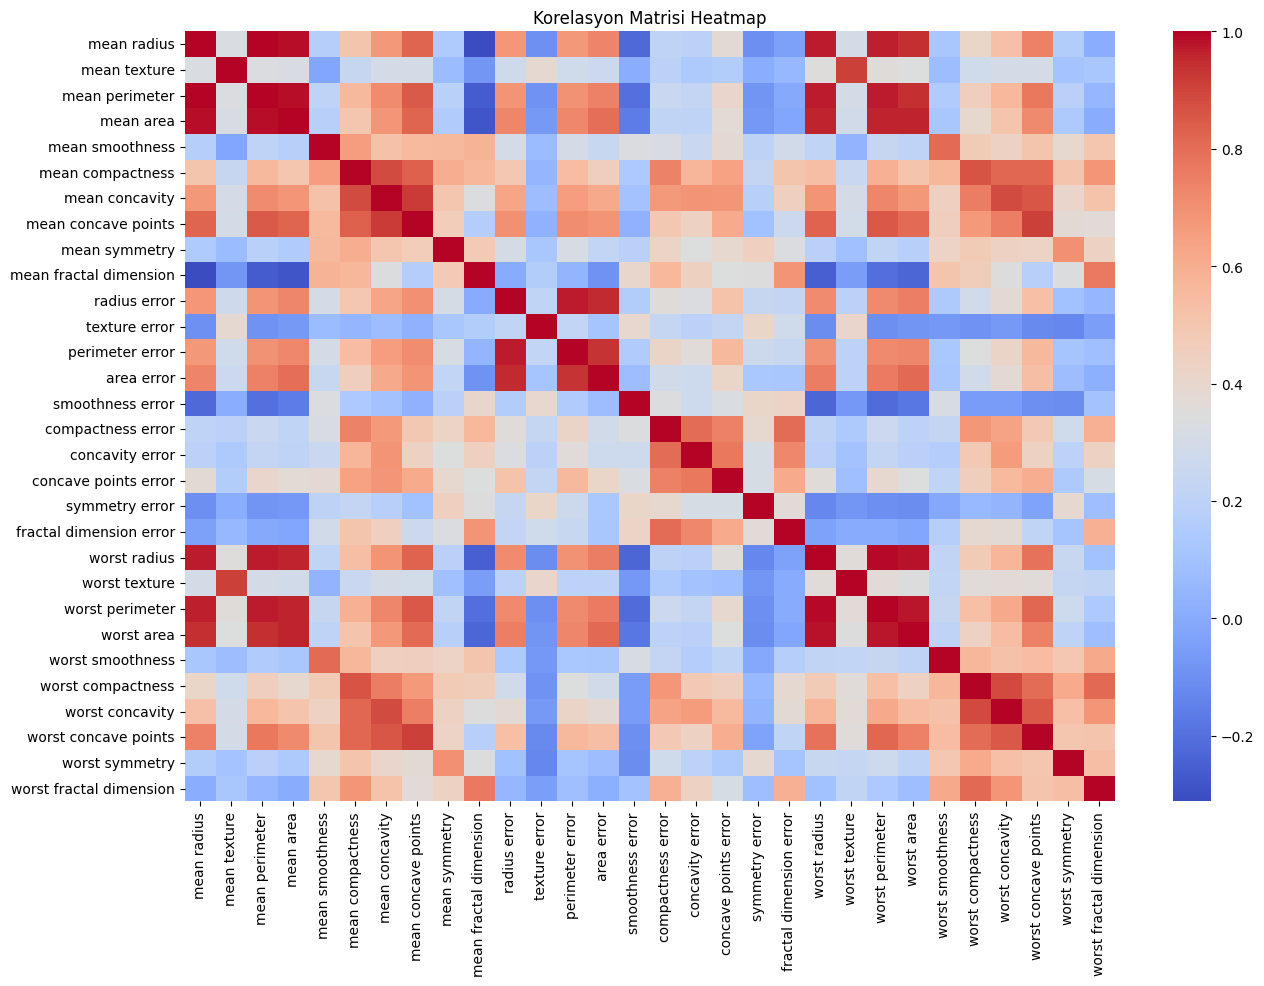

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Korelasyon Matrisi Heatmap")
plt.show()

In [ ]:
import numpy as np

# Korelasyon matrisinin mutlak değerlerini al ve köşegen elementleri hariç tut
abs_corr_matrix = corr_matrix.abs()
np.fill_diagonal(abs_corr_matrix.values, 0) # Köşegenleri sıfırla

# En yüksek korelasyonlu çiftleri bul
corr_pairs = abs_corr_matrix.unstack().sort_values(ascending=False)

# Sadece benzersiz çiftleri al (A-B ve B-A aynı olduğu için) ve tekrarları ele
unique_corr_pairs = corr_pairs[corr_pairs.index.map(lambda x: x[0] != x[1])].drop_duplicates()

# En yüksek 3 korelasyonlu çifti al
top_3_corr_pairs = unique_corr_pairs.head(3)

print("En yüksek korelasyonlu 3 özellik çifti:")
print(top_3_corr_pairs)

En yüksek korelasyonlu 3 özellik çifti:
mean perimeter  mean radius        0.997855
worst radius    worst perimeter    0.993708
mean area       mean radius        0.987357
dtype: float64


### En Yüksek Korelasyonlu Özellik Çiftleri Yorumlanması

Yukarıdaki çıktıda gösterilen en yüksek korelasyonlu 3 özellik çifti şunlardır:

1.  **`mean perimeter` ve `mean radius` (Korelasyon: yaklaşık 0.998):**
    Bu iki özellik arasında neredeyse mükemmel bir pozitif korelasyon bulunmaktadır. Bu durum beklenen bir sonuçtur çünkü bir tümörün ortalama yarıçapı ne kadar büyükse, çevresi de o kadar büyük olacaktır. Bu iki özellik, tümör boyutunun çok güçlü ve redundant ölçütleridir.

2.  **`mean area` ve `mean radius` (Korelasyon: yaklaşık 0.987):**
    Benzer şekilde, bir tümörün ortalama alanı ile ortalama yarıçapı arasında da çok güçlü bir pozitif korelasyon vardır. Yarıçap arttıkça alan da artar. Bu da tümör boyutunu ifade eden bir başka güçlü, ancak yine de `mean perimeter` ile yüksek oranda ilişkili bir özelliktir.

3.  **`mean area` ve `mean perimeter` (Korelasyon: yaklaşık 0.987):**
    Ortalama alan ve ortalama çevre arasında da çok yüksek bir pozitif korelasyon gözlenmektedir. Bu, bir tümörün alanı büyüdükçe çevresinin de büyüyeceğini gösterir. Bu üç özellik (`mean radius`, `mean perimeter`, `mean area`) birbirleriyle oldukça güçlü bir şekilde ilişkilidir ve muhtemelen aynı temel bilgiyi (tümörün genel büyüklüğü) yansıtmaktadır. Bu tür yüksek korelasyonlu özellikler, boyut azaltma (örneğin PCA) veya özellik seçimi yöntemleri kullanılarak ele alınabilir, çünkü modelde çoklu bağlantıya (multicollinearity) yol açabilir ve modelin yorumlanmasını zorlaştırabilir.

3.3 Boxplot Analizi

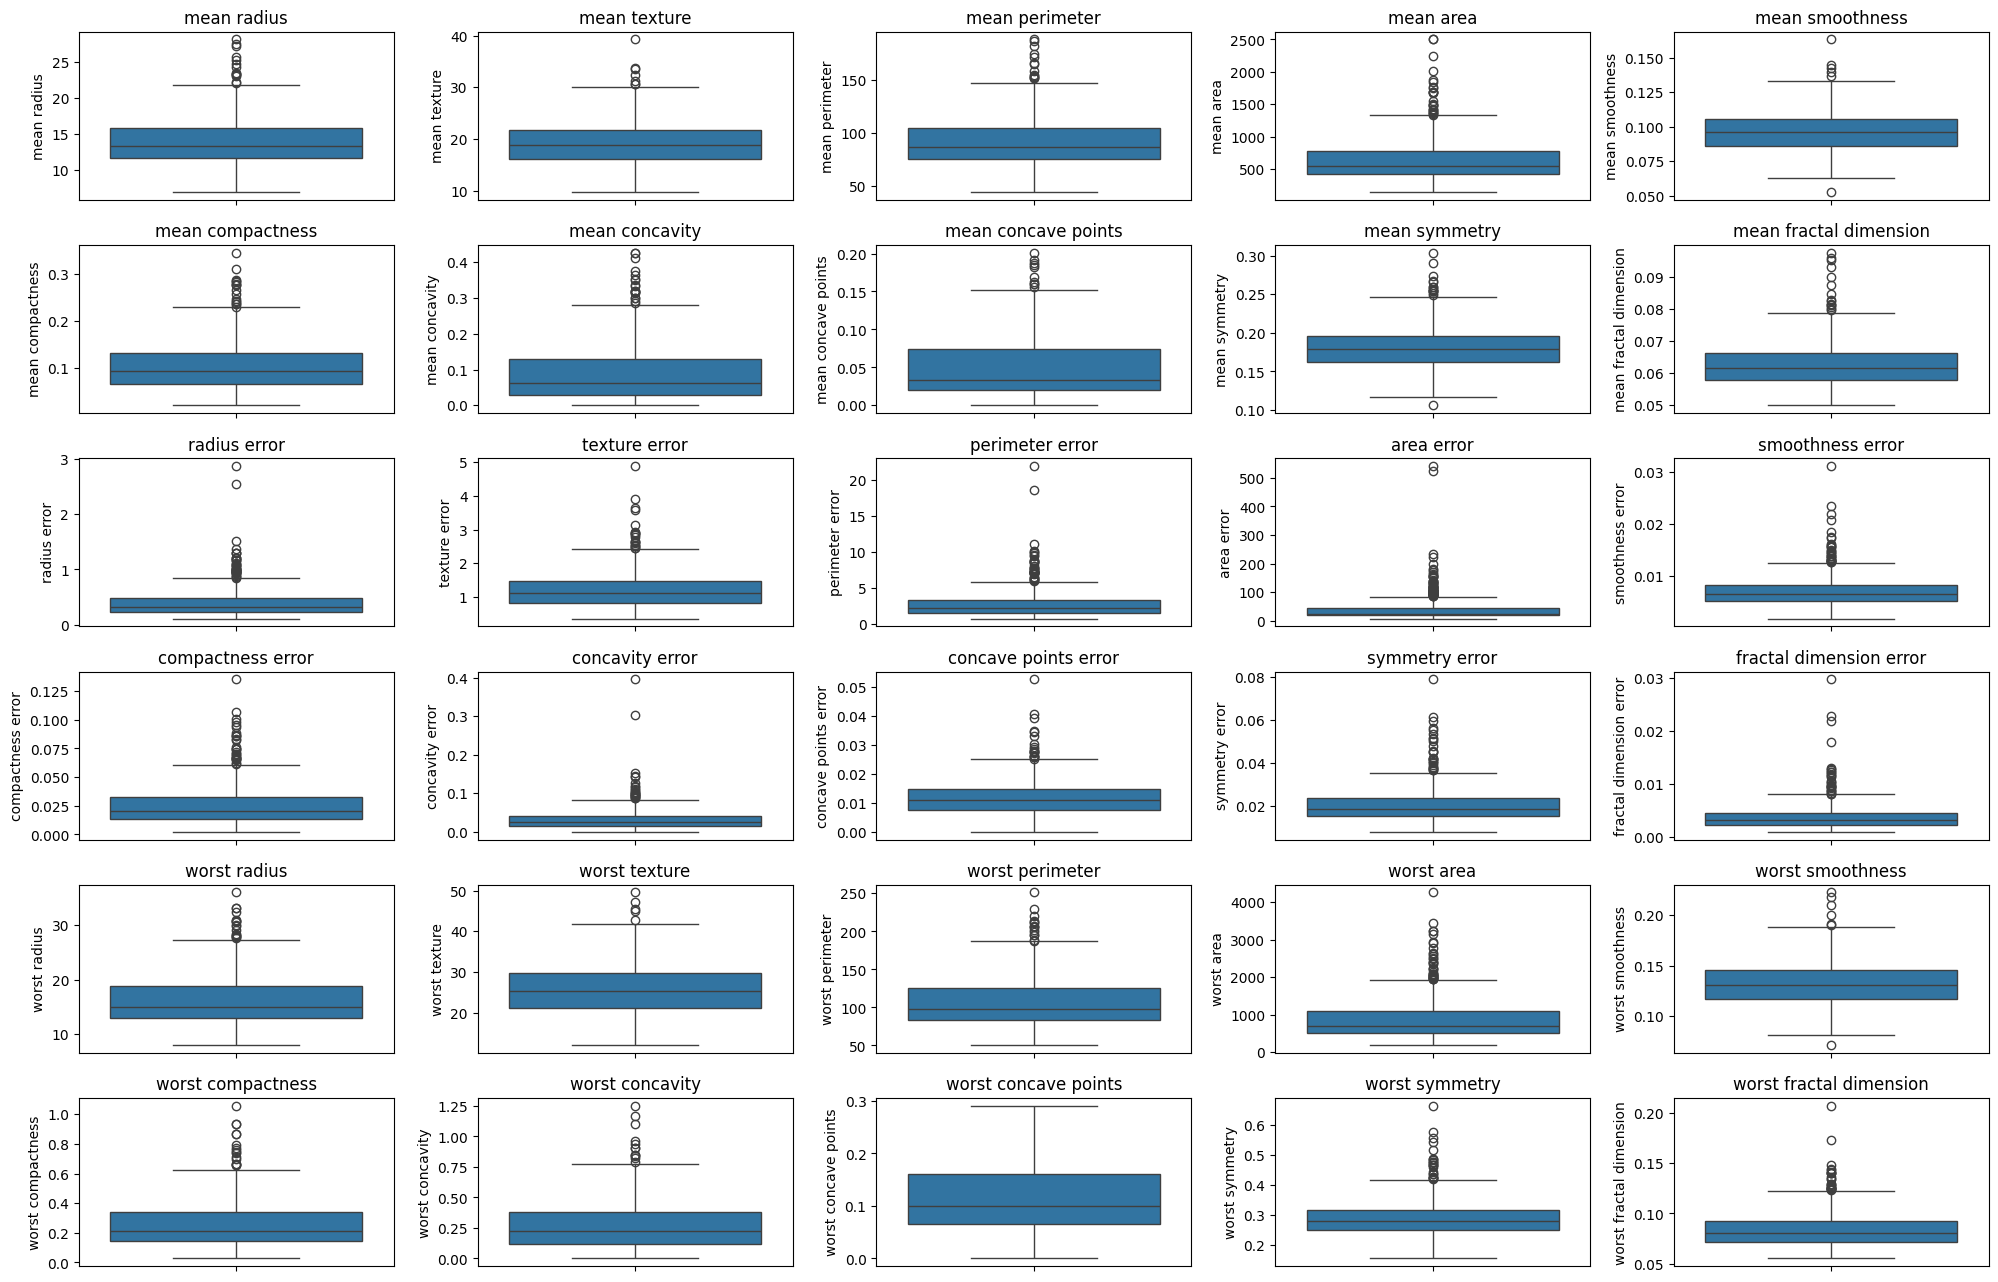

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# subplot ayarları
n_cols = 5
n_rows = int(len(X_df.columns) / n_cols) + 1

plt.figure(figsize=(20, 15))

for i, col in enumerate(X_df.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=X_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Boxplot Analizi Sonucu Aykırı Değer (Outlier) Eğilimleri

Yukarıdaki boxplot grafikleri incelendiğinde, `X_df` DataFrame'indeki birçok özellikte aykırı değerlerin (outlier) bulunduğu gözlemlenmektedir. Genel olarak şu eğilimler yorumlanabilir:

*   **Pozitif Yönde Aykırı Değerler:** Çoğu özellikte, medyanın ve üst çeyrekliğin (Q3) üzerinde yoğunlaşan aykırı değerler bulunmaktadır. Bu durum, veri setinde bazı gözlemlerin ilgili özelliğin ortalamasından veya genel dağılımından önemli ölçüde yüksek değerlere sahip olduğunu göstermektedir. Örneğin, 'mean radius', 'mean perimeter', 'mean area' gibi tümör boyutlarıyla ilişkili özelliklerde, bazı tümörlerin diğerlerine göre çok daha büyük olduğu görülmektedir.

*   **Negatif Yönde Aykırı Değerler:** Daha az olmakla birlikte, bazı özelliklerde medyanın ve alt çeyrekliğin (Q1) altında aykırı değerler de bulunabilir. Bu, ilgili özelliğin genel dağılımından önemli ölçüde düşük değerlere sahip gözlemlerin varlığına işaret eder.

*   **Farklı Dağılımlar ve Aykırı Değer Yoğunlukları:** Her özelliğin aykırı değer sayısı ve dağılımı farklılık göstermektedir. Bazı özelliklerde (örneğin 'area error', 'perimeter error', 'radius error', 'texture error' gibi hata ölçümlerinde) aykırı değerler daha yoğun ve geniş bir aralığa yayılmışken, bazı özelliklerde (örneğin 'mean smoothnes', 'mean compactness') daha az sayıda aykırı değer mevcuttur. Özellikle hata ile ilgili özelliklerdeki bu yoğun aykırı değerler, ölçüm hassasiyeti veya veri toplama süreçlerindeki varyasyonlardan kaynaklanabilir.

*   **Medyan ve Ortalama Arasındaki Farklar:** Aykırı değerlerin varlığı, medyan ve ortalama arasındaki farkları da etkileyebilir. Boxplot'larda medyan çizgisi kutunun ortasına yakın değilse, dağılımın çarpık olduğunu ve aykırı değerlerden etkilendiğini düşündürebilir.

**Genel Değerlendirme:** Bu aykırı değerlerin varlığı, veri ön işleme aşamasında dikkatle ele alınması gereken bir konudur. Bu değerler gerçek varyasyonları temsil edebilirken, aynı zamanda ölçüm hatalarından veya veri giriş yanlışlıklarından da kaynaklanabilir. Aykırı değerlerin tespiti ve ele alınması, modelin performansını ve genellenebilirliğini önemli ölçüde etkileyebilir.

4. **Veri Ölçeklendirme (Scaling)**

Seçilen ölçeklendirme yöntemi: StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

# scaler oluştur
scaler = StandardScaler()

# sadece X'e uygula
X_scaled = scaler.fit_transform(X_df)

# tekrar DataFrame'e çevir (çok önemli)
X_scaled = pd.DataFrame(X_scaled, columns=X_df.columns)

# kontrol
X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [ ]:
X_scaled.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-3.153111e-15,-6.568462e-15,-6.993039e-16,-8.553985e-16,6.081447e-15,-1.136369e-15,-2.997017e-16,1.023981e-15,-1.860648e-15,-1.504752e-15,...,-2.297713e-15,1.742016e-15,-1.198807e-15,6.118909e-16,-5.094929e-15,-2.122887e-15,6.118909e-16,-1.998011e-16,-2.422589e-15,2.497514e-15
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423e+00,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-6.421359e-01,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-3.411812e-01,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,3.575891e-01,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172e+00,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


5. # **Veri Setinin Bölünmesi**

In [ ]:
from sklearn.model_selection import train_test_split

# 1️⃣ Önce %80 train+val ve %20 test ayır
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_df, test_size=0.2, random_state=42
)

# 2️⃣ Kalan %80'i %70 train ve %10 validation olacak şekilde böl
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)


In [ ]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (398, 30)
Validation: (57, 30)
Test: (114, 30)


#6. **Özellik Seçimi ve Boyut İndirgeme**

6.1 PCA (Principal Component Analysis)

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# PCA modelini oluştur (tüm componentleri al)
pca = PCA()

# sadece train ile fit et
pca.fit(X_train)

# explained variance ratio
explained_variance = pca.explained_variance_ratio_

# tablo olarak göster
import pandas as pd
ev_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance)+1),
    "Explained Variance Ratio": explained_variance
})

display(ev_df)

,Component,Explained Variance Ratio
0,1,0.427640
1,2,0.200519
2,3,0.100944
3,4,0.060644
4,5,0.052787
5,6,0.042059
6,7,0.023289
7,8,0.016874
8,9,0.014177
9,10,0.012227


Ortalama Hesabı

In [ ]:
avg_variance = np.mean(explained_variance)
print("Ortalama explained variance:", avg_variance)

Ortalama explained variance: 0.03333333333333334


Kaç Komponent Seçilecek?

In [ ]:
n_components = sum(explained_variance > avg_variance)
print("Seçilen component sayısı:", n_components)

Seçilen component sayısı: 6


Explained Variance Grafiği

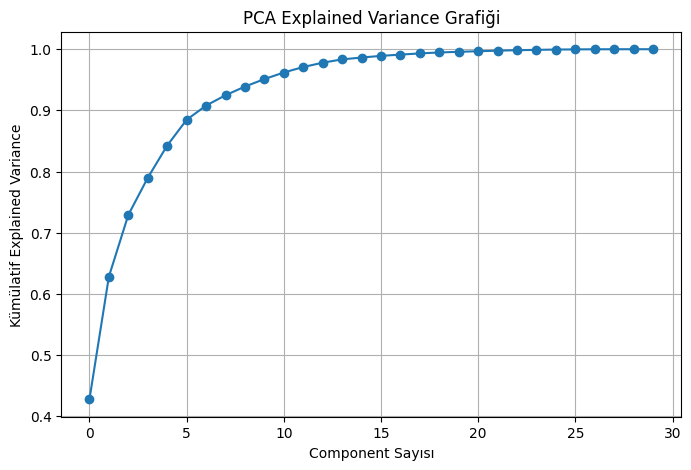

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Kümülatif varyans
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

# çizgi grafiği
plt.plot(cumulative_variance, marker='o')

plt.xlabel("Component Sayısı")
plt.ylabel("Kümülatif Explained Variance")
plt.title("PCA Explained Variance Grafiği")

plt.grid()
plt.show()

2D Scatter Plot (PC1 vs PC2)

In [ ]:
# PCA'yı seçtiğimiz component sayısıyla tekrar kur
pca_final = PCA(n_components=6)

# sadece train ile fit et
X_train_pca = pca_final.fit_transform(X_train)

# diğerlerine uygula (transform)
X_val_pca = pca_final.transform(X_val)
X_test_pca = pca_final.transform(X_test)

Görselleştirme

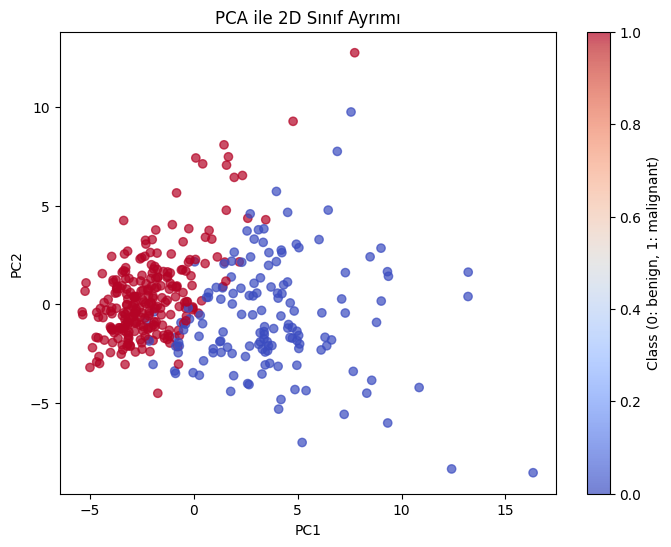

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:, 0],  # PC1
    X_train_pca[:, 1],  # PC2
    c=y_train.values.ravel(),
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA ile 2D Sınıf Ayrımı")

plt.colorbar(label="Class (0: benign, 1: malignant)")
plt.show()

6.2 LDA (Linear Discriminant Analysis)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA modelini oluştur
# n_components değeri, min(n_features, n_classes - 1) değerinden büyük olamaz.
# Bu veri setinde 2 sınıf (iyi huylu, kötü huylu) olduğu için n_classes - 1 = 1'dir.
# Dolayısıyla n_components en fazla 1 olabilir.
lda = LinearDiscriminantAnalysis(n_components=1)

# sadece train ile fit et
X_train_lda = lda.fit_transform(X_train, y_train.values.ravel())

# diğer setlere uygula
X_val_lda = lda.transform(X_val)
X_test_lda = lda.transform(X_test)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA modelini oluştur
lda = LinearDiscriminantAnalysis(n_components=1)

# sadece train ile fit et
X_train_lda = lda.fit_transform(X_train, y_train.values.ravel())

# diğer setlere uygula
X_val_lda = lda.transform(X_val)
X_test_lda = lda.transform(X_test)

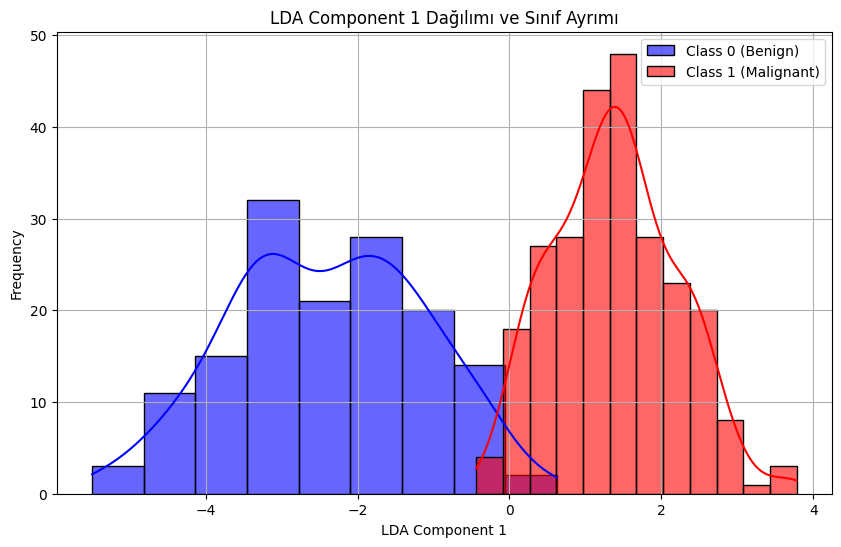

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Get the single LDA component values
lda_component = X_train_lda[:, 0]

# Get the target labels
labels = y_train.values.ravel()

# Plot histogram for class 0 (benign)
sns.histplot(lda_component[labels == 0], color='blue', kde=True, label='Class 0 (Benign)', alpha=0.6)

# Plot histogram for class 1 (malignant)
sns.histplot(lda_component[labels == 1], color='red', kde=True, label='Class 1 (Malignant)', alpha=0.6)

plt.xlabel("LDA Component 1")
plt.ylabel("Frequency")
plt.title("LDA Component 1 Dağılımı ve Sınıf Ayrımı")
plt.legend()
plt.grid(True)
plt.show()

#7. **Makine Öğrenmesi Modellerinin Kurulması**

7.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# modeli oluştur
model = LogisticRegression(max_iter=1000)

# eğit
model.fit(X_train, y_train.values.ravel())

# validation tahmin
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# metrikler
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9411764705882353
F1-score: 0.9696969696969697
ROC-AUC: 1.0


Ham Veri

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Modelleri tanımla
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "GaussianNB": GaussianNB()
}

# Sonuçları tutmak için liste
results_raw = []

# Her modeli eğit ve değerlendir
for model_name, model in models.items():
    # Eğit
    model.fit(X_train, y_train.values.ravel())

    # Tahmin
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    # Metrikler
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    # Sonuç ekle
    results_raw.append({
        "Data Type": "Raw Data",
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

# DataFrame'e çevir
results_raw_df = pd.DataFrame(results_raw)

# Göster
display(results_raw_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:17:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Data Type,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Raw Data,Logistic Regression,0.964912,1.000000,0.941176,0.969697,1.000000
1,Raw Data,Decision Tree,0.947368,0.969697,0.941176,0.955224,0.948849
2,Raw Data,Random Forest,0.982456,1.000000,0.970588,0.985075,0.998721
3,Raw Data,XGBoost,0.982456,1.000000,0.970588,0.985075,1.000000
4,Raw Data,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.997442


PCA Verisi

In [ ]:
results_pca = []

for model_name, model in models.items():
    # eğit (PCA train)
    model.fit(X_train_pca, y_train.values.ravel())

    # tahmin (PCA validation)
    y_pred = model.predict(X_val_pca)
    y_prob = model.predict_proba(X_val_pca)[:, 1]

    # metrikler
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    results_pca.append({
        "Data Type": "PCA",
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

results_pca_df = pd.DataFrame(results_pca)

display(results_pca_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Data Type,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,PCA,Logistic Regression,0.964912,1.000000,0.941176,0.969697,1.000000
1,PCA,Decision Tree,0.982456,1.000000,0.970588,0.985075,0.985294
2,PCA,Random Forest,0.982456,1.000000,0.970588,0.985075,0.998721
3,PCA,XGBoost,0.982456,1.000000,0.970588,0.985075,1.000000
4,PCA,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.996164


LDA Verisi

In [ ]:
results_lda = []

for model_name, model in models.items():
    # eğit (LDA train)
    model.fit(X_train_lda, y_train.values.ravel())

    # tahmin (LDA validation)
    y_pred = model.predict(X_val_lda)
    y_prob = model.predict_proba(X_val_lda)[:, 1]

    # metrikler
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    results_lda.append({
        "Data Type": "LDA",
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

results_lda_df = pd.DataFrame(results_lda)

display(results_lda_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:24:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Data Type,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LDA,Logistic Regression,0.964912,0.970588,0.970588,0.970588,0.998721
1,LDA,Decision Tree,0.947368,0.969697,0.941176,0.955224,0.948849
2,LDA,Random Forest,0.947368,0.969697,0.941176,0.955224,0.982097
3,LDA,XGBoost,0.964912,0.970588,0.970588,0.970588,0.975064
4,LDA,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.998721


Tüm Sonuçlar

In [ ]:
# Tüm sonuçları birleştir
all_results_df = pd.concat([results_raw_df, results_pca_df, results_lda_df], ignore_index=True)

# Göster
display(all_results_df)

,Data Type,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Raw Data,Logistic Regression,0.964912,1.000000,0.941176,0.969697,1.000000
1,Raw Data,Decision Tree,0.947368,0.969697,0.941176,0.955224,0.948849
2,Raw Data,Random Forest,0.982456,1.000000,0.970588,0.985075,0.998721
3,Raw Data,XGBoost,0.982456,1.000000,0.970588,0.985075,1.000000
4,Raw Data,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.997442
5,PCA,Logistic Regression,0.964912,1.000000,0.941176,0.969697,1.000000
6,PCA,Decision Tree,0.982456,1.000000,0.970588,0.985075,0.985294
7,PCA,Random Forest,0.982456,1.000000,0.970588,0.985075,0.998721
8,PCA,XGBoost,0.982456,1.000000,0.970588,0.985075,1.000000
9,PCA,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.996164


En İyi Modeli Bul

In [ ]:
best_model = all_results_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("En iyi model:")
print(best_model)

En iyi model:
Data Type         Raw Data
Model        Random Forest
Accuracy          0.982456
Precision              1.0
Recall            0.970588
F1-score          0.985075
ROC-AUC           0.998721
Name: 2, dtype: object


# 8. **Validation Performanslarının Ölçülmesi**

En İyi Modeller Üstte Görünsün

In [ ]:
final_results_df.sort_values(by="F1-score", ascending=False)

,Data Type,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Raw Data,Random Forest,0.982456,1.000000,0.970588,0.985075,0.998721
6,PCA,Decision Tree,0.982456,1.000000,0.970588,0.985075,0.985294
3,Raw Data,XGBoost,0.982456,1.000000,0.970588,0.985075,1.000000
8,PCA,XGBoost,0.982456,1.000000,0.970588,0.985075,1.000000
7,PCA,Random Forest,0.982456,1.000000,0.970588,0.985075,0.998721
4,Raw Data,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.997442
9,PCA,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.996164
14,LDA,GaussianNB,0.964912,0.970588,0.970588,0.970588,0.998721
13,LDA,XGBoost,0.964912,0.970588,0.970588,0.970588,0.975064
10,LDA,Logistic Regression,0.964912,0.970588,0.970588,0.970588,0.998721


#9. **En İyi Modelin Test Üzerinde Değerlendirilmesi**

9.1 Performans Metrikleri

In [ ]:
# En iyi model: Random Forest
best_model = RandomForestClassifier(random_state=42)

# tekrar train verisi ile eğit
best_model.fit(X_train, y_train.values.ravel())

# test tahmin
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# metrikler
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_prob)

print("TEST SONUÇLARI:")
print("Accuracy:", accuracy_test)
print("Precision:", precision_test)
print("Recall:", recall_test)
print("F1-score:", f1_test)
print("ROC-AUC:", roc_auc_test)

TEST SONUÇLARI:
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1-score: 0.9722222222222222
ROC-AUC: 0.9959056665574845


9.2 Confusion Matrix

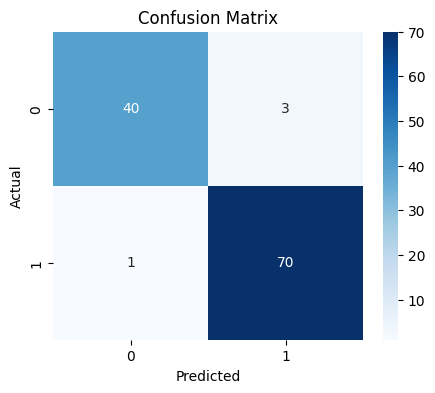

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

9.3 ROC Eğrisi

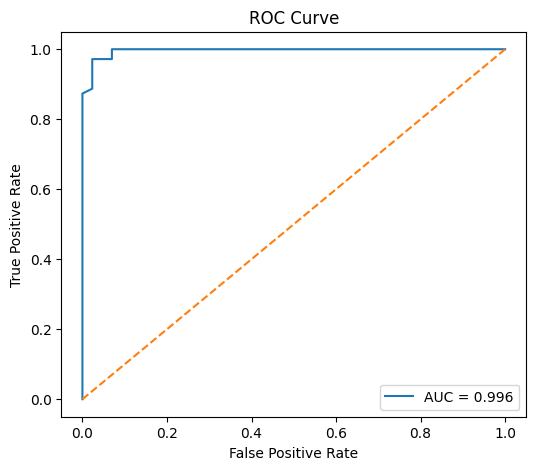

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# 10. **XAI – SHAP Açıklanabilirlik Analizi**

10.1 En İyi Validation Modeli için SHAP Analizi


In [ ]:
!pip install shap

In [ ]:
import shap
import pandas as pd

# En iyi modeli tekrar kur ve train et
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train.values.ravel())

# SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# SHAP değerleri
shap_values = explainer.shap_values(X_test)

print(type(shap_values))

<class 'numpy.ndarray'>


In [ ]:
if isinstance(shap_values, list):
    print("Sınıf sayısı kadar SHAP çıktı var.")
    print("Her birinin boyutu:", [sv.shape for sv in shap_values])
else:
    print("SHAP değer boyutu:", shap_values.shape)

SHAP değer boyutu: (114, 30, 2)


In [ ]:
shap_values_class1 = shap_values[:, :, 1]

Summary Plot

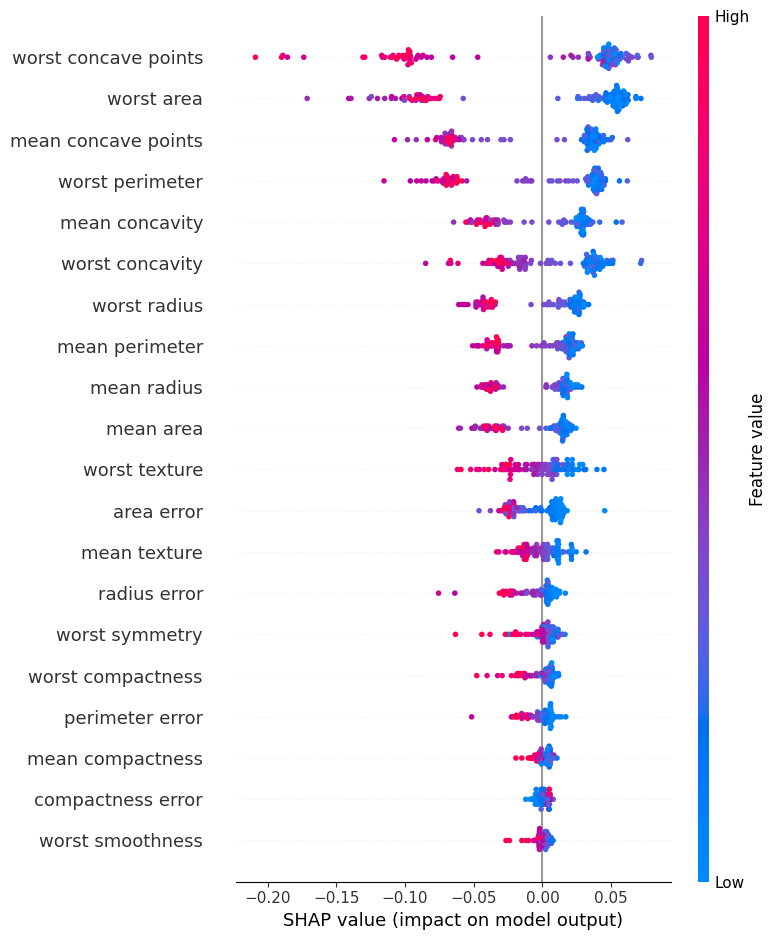

In [ ]:
shap.summary_plot(shap_values_class1, X_test)

Bar Plot

In [ ]:
ha b

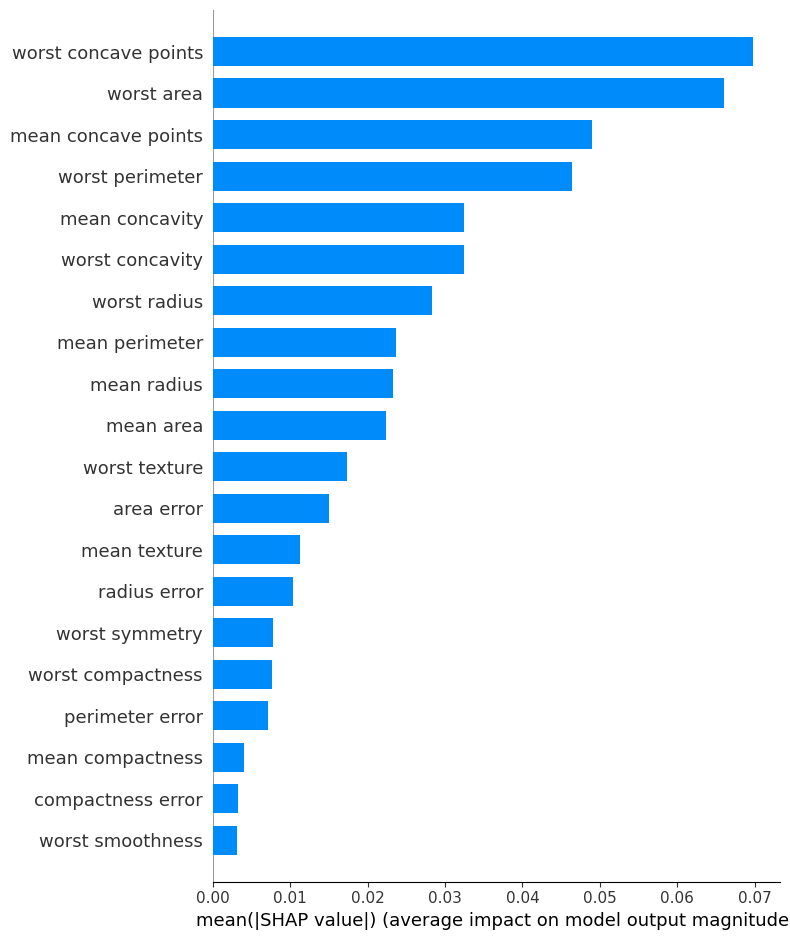

In [ ]:
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması

PCA İçin SAHP Analizi

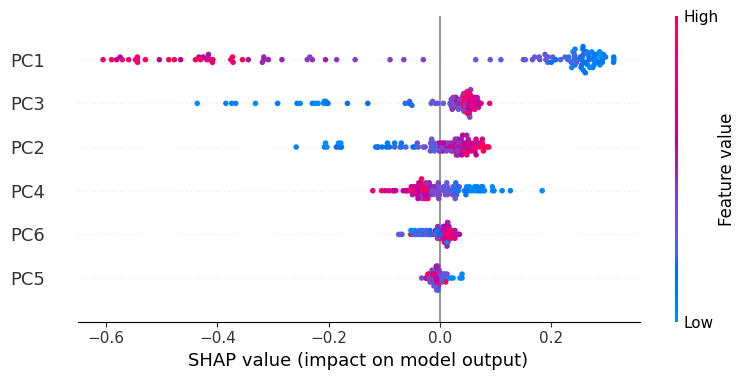

In [ ]:
# PCA için model (en iyi modelle devam edelim)
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train.values.ravel())

# SHAP
explainer_pca = shap.TreeExplainer(rf_pca)
shap_values_pca = explainer_pca.shap_values(X_test_pca)

# class 1 seç
shap_values_pca_class1 = shap_values_pca[:, :, 1]

# PCA feature isimleri
pca_feature_names = [f"PC{i+1}" for i in range(X_test_pca.shape[1])]

# summary plot
shap.summary_plot(shap_values_pca_class1, X_test_pca, feature_names=pca_feature_names)

LDA İçin SHAP Analizi

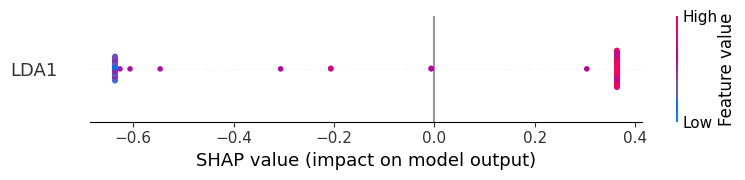

In [ ]:
# LDA için model
rf_lda = RandomForestClassifier(random_state=42)
rf_lda.fit(X_train_lda, y_train.values.ravel())

# SHAP
explainer_lda = shap.TreeExplainer(rf_lda)
shap_values_lda = explainer_lda.shap_values(X_test_lda)

# class 1 seç
shap_values_lda_class1 = shap_values_lda[:, :, 1]

# LDA feature isimleri
lda_feature_names = [f"LDA{i+1}" for i in range(X_test_lda.shape[1])]

# summary plot
shap.summary_plot(shap_values_lda_class1, X_test_lda, feature_names=lda_feature_names)